# Import necessary libraries



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Input
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy


# Define dataset paths

In [3]:
train_dir = "/content/drive/MyDrive/finalyearproject/Training"
test_dir = "/content/drive/MyDrive/finalyearproject/Testing"


# Define class names


In [4]:
class_names = ["glioma", "meningioma", "notumor", "pituitary"]


# Function to resize and normalize images


In [5]:
def resize_rescaling(image, label):
    image = tf.image.resize(image, (224, 224)) / 255.0  # Resize and normalize
    return image, label

# Load and preprocess training dataset


In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",  # Integer labels for sparse categorical loss
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
).map(resize_rescaling).prefetch(tf.data.AUTOTUNE)

Found 5712 files belonging to 4 classes.


# Load and preprocess testing dataset


In [7]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
).map(resize_rescaling).prefetch(tf.data.AUTOTUNE)

Found 1311 files belonging to 4 classes.


# ResNet Backbone

# Load ResNet152V2 model (pre-trained)


In [8]:

resnet_backbone = ResNet152V2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"  # Global average pooling
)

# Freeze pretrained layers
resnet_backbone.trainable = False

# Define the classification model
inputs = Input(shape=(224, 224, 3))
x = resnet_backbone(inputs)
x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
outputs = Dense(len(class_names), activation="softmax")(x)  # Multi-class classification

Resnet_model = Model(inputs, outputs, name="Brain_Tumor_Classifier")


234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Compile the model

In [9]:
Resnet_model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=Adam(learning_rate=0.0001),
    metrics=["accuracy"]
)

Verify Data Shape

In [10]:
for images, labels in train_dataset.take(1):
    print(f"Batch Image Shape: {images.shape}")  # Should be (32, 224, 224, 3)


Batch Image Shape: (32, 224, 224, 3)


In [11]:
from sklearn.utils.class_weight import compute_class_weight

# Define class distribution
num_images = {
    "glioma": 1305,
    "meningioma": 1326,
    "notumor": 1591,
    "pituitary": 1433
}

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2, 3]),  # Class indices
    y=np.concatenate([
        np.full(num_images["glioma"], 0),
        np.full(num_images["meningioma"], 1),
        np.full(num_images["notumor"], 2),
        np.full(num_images["pituitary"], 3)
    ])
)

# Convert to dictionary format for TensorFlow
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class Weights:", class_weights_dict)


Class Weights: {0: 1.0833333333333333, 1: 1.0661764705882353, 2: 0.8885920804525456, 3: 0.9865666434054431}


# Train the model


In [12]:
Resnet_model.fit(train_dataset, validation_data=test_dataset, epochs=20, verbose=1, class_weight=class_weights_dict)


Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 1031s 6s/step - accuracy: 0.5625 - loss: 1.1035 - val_accuracy: 0.7872 - val_loss: 0.5509
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 45s 251ms/step - accuracy: 0.8550 - loss: 0.4415 - val_accuracy: 0.8528 - val_loss: 0.3938
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 231ms/step - accuracy: 0.8922 - loss: 0.3255 - val_accuracy: 0.8825 - val_loss: 0.3200
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 83s 236ms/step - accuracy: 0.9297 - loss: 0.2400 - val_accuracy: 0.9062 - val_loss: 0.2746
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 44s 245ms/step - accuracy: 0.9511 - loss: 0.1850 - val_accuracy: 0.9153 - val_loss: 0.2400
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 42s 232ms/step - accuracy: 0.9622 - loss: 0.1526 - val_accuracy: 0.9207 - val_loss: 0.2223
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 44s 246ms/step - accuracy: 0.9675 - loss: 0.1289 - val_accuracy: 0.9222 - val_loss: 0.2134
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 45s 248ms/step - accuracy: 0.9746 - loss: 0.

# Evaluate the model on test data


41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.9314 - loss: 0.1826
Test Accuracy: 95.42%
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━

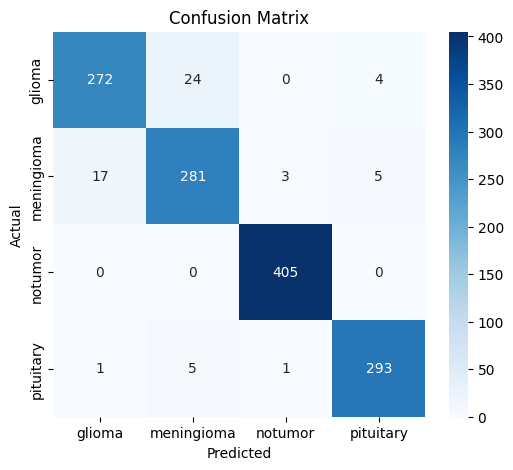

              precision    recall  f1-score   support

      glioma       0.94      0.91      0.92       300
  meningioma       0.91      0.92      0.91       306
     notumor       0.99      1.00      1.00       405
   pituitary       0.97      0.98      0.97       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.95      0.95      0.95      1311



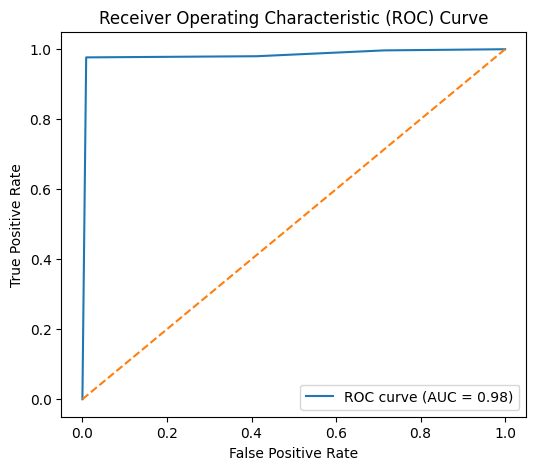

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

# Evaluate on test dataset
test_loss, test_acc = Resnet_model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = Resnet_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_true, np.array(y_pred), pos_label=3)  # Example for 'pituitary'
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()


Check Prediction on Single Image

In [14]:
def predict_tumor(image_path):
    # Load image
    image = cv2.imread(image_path)

    if image is None:
        print("Error: Image not found or path is incorrect.")
        return

    # Convert grayscale to RGB if needed
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Resize and normalize
    image = cv2.resize(image, (224, 224)) / 255.0
    image = np.expand_dims(image, axis=0)  # Add batch dimension

    # Predict
    pred = Resnet_model.predict(image)

    # Print confidence scores
    print("\nPrediction Confidence Scores:")
    for i, tumor_class in enumerate(class_names):
        print(f"{tumor_class}: {pred[0][i] * 100:.2f}%")

    # Get the predicted class
    predicted_label = class_names[np.argmax(pred)]

    # Display the image with prediction result
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted Tumor Type: {predicted_label}")
    plt.axis("off")
    plt.show()

    return predicted_label


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Prediction Confidence Scores:
glioma: 0.70%
meningioma: 90.55%
notumor: 8.22%
pituitary: 0.53%


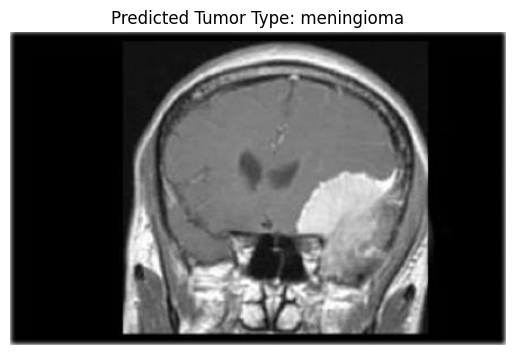

'meningioma'

In [15]:
# Test with an MRI image path
image_path = "/content/drive/MyDrive/finalyearproject/Testing/meningioma/Te-meTr_0000.jpg"
predict_tumor(image_path)


In [16]:
Resnet_model.save('/content/drive/MyDrive/finalyearproject/Resnetfinalnew_model.h5')

#Load model

In [17]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("/content/drive/MyDrive/finalyearproject/Resnetfinalnew_model.h5")


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
glioma: 1.94%
meningioma: 0.26%
notumor: 0.04%
pituitary: 97.77%


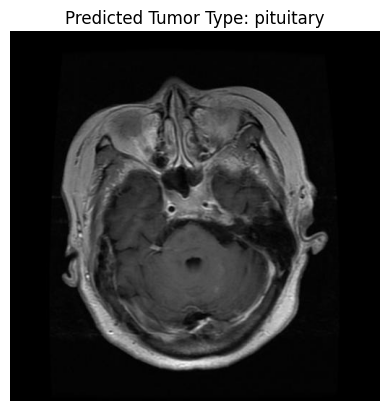

'pituitary'

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class_names = ["glioma", "meningioma", "notumor", "pituitary"]  # Define class labels

def predict_tumor(image_path, model):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (224, 224)) / 255.0  # Resize and normalize
    image = np.expand_dims(image, axis=0)  # Add batch dimension
    pred = model.predict(image)

    # Print confidence scores
    for i, tumor_class in enumerate(class_names):
        print(f"{tumor_class}: {pred[0][i] * 100:.2f}%")

    predicted_label = class_names[np.argmax(pred)]

    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted Tumor Type: {predicted_label}")
    plt.axis("off")
    plt.show()

    return predicted_label

# Example Usage
image_path = "/content/drive/MyDrive/finalyearproject/Testing/pituitary/Te-pi_0029.jpg"  # Replace with your image path
predict_tumor(image_path, model)
